# Guided DDIM Reconstruction – EM Neuron Data (No Ground Truth)

Test the conditional LA-Diff diffusion model trained with `train_conditional_large_ladiff.py`
on EM electron microscopy data where **no ground truth is available**.

**Pipeline:**
1. Load the EM tomogram (`synapse-bin4-5i-demo.npy`) – already has the missing wedge.
2. Load the norm sidecar JSON and define normalisation functions.
3. Load the trained conditional UNet checkpoint.
4. Run Guided DDIM with Fourier inpainting consistency.
5. Compare qualitatively against the **IsoNet-corrected** baseline.

Since there is no ground truth, SSIM between DDIM ↔ LA-FBP and DDIM ↔ IsoNet are used
as proxy metrics to track convergence.

## 1. Imports & Setup

In [1]:
import sys, importlib, json, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch

# ── Project paths ─────────────────────────────────────────────────────────
project_root = Path('/myhome/sdate')
sys.path.insert(0, str(project_root))
sys.path.insert(0, '/myhome/astra-torch')
sys.path.insert(0, '/myhome/chip-project')

from ladiff.fourier_wedge import (
    build_missing_wedge_mask,
    apply_missing_wedge,
    inpaint_fourier_wedge,
    apply_circle_mask,
)

# ── Diffusion model / pipeline ────────────────────────────────────────────
from diffusers.models import UNet2DModel
from ladiff.schedulers.scheduling_ddim import GuidedDDIMScheduler
from ladiff.schedulers.pipeline_ddim import DDIMPipeline

# ── Metrics ───────────────────────────────────────────────────────────────
from skimage.metrics import structural_similarity as compute_ssim

import lovely_tensors as lt
lt.monkey_patch()

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['image.cmap'] = 'gray'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}  |  PyTorch {torch.__version__}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name()}")

def fft_2D(x, s=None, ortho:bool=False, dim=[-1, -2]):
    # if len(x.shape) == 2:
    #     raise Exception("Expects at least dimensions (b, w, h)")
    if ortho:
        fft_image = torch.fft.fftn(x, s=s, norm='ortho', dim=dim)
    else:
        fft_image = torch.fft.fftn(x, s=s, dim=dim)
    return torch.fft.fftshift(fft_image, dim=dim)


def ifft_2D(x, ortho:bool=False, dim=[-1, -2]):
    # if len(x.shape) == 2:
    #     raise Exception("Expects at least dimensions (b, w, h)")
    f_space = torch.fft.ifftshift(x, dim=dim)
    # Perform inverse 2D Fourier Transform
    if ortho:
        return torch.fft.ifftn(f_space, norm='ortho', dim=dim)
    else:
        return torch.fft.ifftn(f_space, dim=dim)


Matplotlib is building the font cache; this may take a moment.


zarr not installed


/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda  |  PyTorch 2.8.0+cu128
GPU: NVIDIA A100 80GB PCIe


## 2. Configuration

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────
RECON_PATH  = Path('/myhome/data/sdate/shared/em_data_npy/neuron')
DATA_PATH   = RECON_PATH / 'synapse-bin4-5i-demo.npy'
# No ground truth — the input IS the best available reference
GT_FBP_PATH = DATA_PATH
NORM_JSON   = RECON_PATH / 'synapse-bin4-5i-demo_norm.json'
ISONET_PATH = RECON_PATH / 'synapse-bin4-5i-demo_corrected.npy'

CHECKPOINT_PATH = project_root / 'checkpoints' / 'ddpm_ladiff_cond_ladiff_neuron.pt'

# ── Acquisition geometry ──────────────────────────────────────────────────
CONE_WIDTH_DEG       = 60.0    # missing cone width in degrees
GAMMA_CORRECTION_DEG = -6.0   # rotation offset of the missing cone from canonical 0°
TILT_AXIS            = 0       # axis the sample rotates around (0=kz, as set by em_io permute)

# ── Inference ─────────────────────────────────────────────────────────────
NUM_INFERENCE_STEPS = 50
TEST_STRIDE         = 10    # evaluate every N-th slice (when TEST_SLICE_INDICES=None)
TEST_SLICE_INDICES  = None  # override with e.g. [50, 100, 150] for specific slices
SEED                = 0

print(f"Data     : {DATA_PATH}")
print(f"IsoNet   : {ISONET_PATH}")
print(f"Checkpoint: {CHECKPOINT_PATH}")
print(f"Cone width: {CONE_WIDTH_DEG}°  |  Gamma: {GAMMA_CORRECTION_DEG}°  |  Tilt axis: {TILT_AXIS}")

Data     : /myhome/data/sdate/shared/em_data_npy/neuron/synapse-bin4-5i-demo.npy
IsoNet   : /myhome/data/sdate/shared/em_data_npy/neuron/synapse-bin4-5i-demo_corrected.npy
Checkpoint: /myhome/sdate/checkpoints/ddpm_ladiff_cond_ladiff_neuron.pt
Cone width: 60.0°  |  Gamma: -6.0°  |  Tilt axis: 0


## 3. Load EM Volume and Normalization

In [3]:
# Angular range that IS covered (complement of the missing cone)
ANGULAR_RANGE_DEG = int(180 - CONE_WIDTH_DEG)   # 120 for CONE_WIDTH_DEG=60
# Centre the covered range and account for the gamma rotation of the missing cone
START_ANGLE = int((180 - ANGULAR_RANGE_DEG) // 2)  # e.g. 30 - (-6) = 36

print(f"CONE_WIDTH_DEG   = {CONE_WIDTH_DEG}°")
print(f"ANGULAR_RANGE_DEG= {ANGULAR_RANGE_DEG}°  (covered)")
print(f"START_ANGLE      = {START_ANGLE}° ")
print(f"TILT_AXIS        = {TILT_AXIS}")

CONE_WIDTH_DEG   = 60.0°
ANGULAR_RANGE_DEG= 120°  (covered)
START_ANGLE      = 30° 
TILT_AXIS        = 0


In [4]:
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode

# ── Load the EM tomogram (already has the missing wedge from acquisition) ──
la_fbp_np = np.load(DATA_PATH)          # (N, H, W) — tilt axis permuted to axis 0 by em_io
la_fbp_orig    = torch.tensor(la_fbp_np)     # float32 tensor
la_fbp_orig    = apply_circle_mask(la_fbp_orig)

isonet = torch.tensor(np.load(ISONET_PATH))
isonet    = apply_circle_mask(isonet)



# Correct for the gamma rotation offset: rotate each slice by GAMMA_CORRECTION_DEG
la_fbp_orig = TF.rotate(
    la_fbp_orig.unsqueeze(1),              # (N, 1, H, W) — add channel dim for torchvision
    angle=-GAMMA_CORRECTION_DEG,
    interpolation=InterpolationMode.BILINEAR,
).squeeze(1)

isonet = TF.rotate(
    isonet.unsqueeze(1),              # (N, 1, H, W) — add channel dim for torchvision
    angle=-GAMMA_CORRECTION_DEG,
    interpolation=InterpolationMode.BILINEAR,
).squeeze(1)     

# la_fbp = apply_missing_wedge(isonet.to(device), ANGULAR_RANGE_DEG, START_ANGLE, TILT_AXIS).cpu()
# la_fbp    = apply_circle_mask(la_fbp)
la_fbp = la_fbp_orig

print(f"la_fbp shape : {la_fbp.shape}  dtype={la_fbp.dtype}")
print(f"la_fbp range : [{la_fbp.min():.4f}, {la_fbp.max():.4f}]")

# Display percentile range for visualisation
metric_min = float(np.percentile(la_fbp_np, 1))
metric_max = float(np.percentile(la_fbp_np, 99))
print(f"p1={metric_min:.4f}  p99={metric_max:.4f}")

# ── Normalization from sidecar JSON ───────────────────────────────────────
with open(NORM_JSON) as f:
    norm_cfg = json.load(f)

norm_min = float(norm_cfg['norm_min'])
norm_max = float(norm_cfg['norm_max'])
print(f"\nNorm: min={norm_min:.4f}, max={norm_max:.4f}  (from {NORM_JSON.name})")

def normalize_fn(x: torch.Tensor) -> torch.Tensor:
    return apply_circle_mask((x - norm_min) / (norm_max - norm_min))

def denormalize_fn(x: torch.Tensor) -> torch.Tensor:
    return apply_circle_mask(x * (norm_max - norm_min) + norm_min)

NUM_SLICES, SLICE_H, SLICE_W = la_fbp.shape
print(f"\nVolume: {NUM_SLICES} slices of {SLICE_H}×{SLICE_W}")


la_fbp shape : torch.Size([256, 256, 256])  dtype=torch.float32
la_fbp range : [0.0000, 1.0000]
p1=0.0000  p99=1.0000

Norm: min=0.0000, max=1.0000  (from synapse-bin4-5i-demo_norm.json)

Volume: 256 slices of 256×256


## 4. Compute Geometry Parameters

The EM tomogram already contains the missing wedge.  We set up the geometry parameters
(`ANGULAR_RANGE_DEG`, `START_ANGLE`) that describe the **acquired** angular range so
that the Fourier inpainting guidance preserves the known Fourier data and only fills in
the missing cone.

`GAMMA_CORRECTION_DEG = -6.0` means the missing cone centre is rotated −6° from the
canonical 0° convention. The `START_ANGLE` is adjusted accordingly.

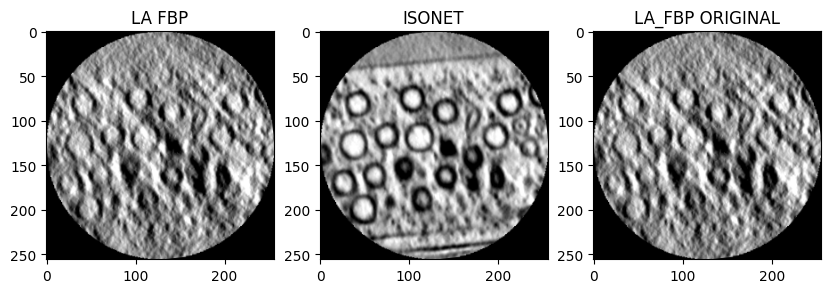

(tensor[20, 256, 256] n=1310720 (5Mb) x∈[0., 1.000] μ=0.421 σ=0.302,
 tensor[20, 256, 256] n=1310720 (5Mb) x∈[0., 1.000] μ=0.440 σ=0.318)

In [5]:
IDX = 0

# NUM_SLICES = 2
# gt_fbp = gt_fbp[:NUM_SLICES]

NUM_SLICES = 20
la_fbp = la_fbp[IDX].unsqueeze(0).repeat(NUM_SLICES, 1, 1)
isonet = isonet[IDX].unsqueeze(0).repeat(NUM_SLICES, 1, 1)
la_fbp_orig = la_fbp_orig[IDX].unsqueeze(0).repeat(NUM_SLICES, 1, 1)

# show la_fbp and isonet first slice
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.imshow(la_fbp[0], vmin=metric_min, vmax=metric_max)
plt.title("LA FBP")
plt.subplot(1, 3, 2)
plt.imshow(isonet[0], vmin=metric_min, vmax=metric_max)
plt.title("ISONET")

plt.subplot(1, 3, 3)
plt.imshow(la_fbp_orig[0], vmin=metric_min, vmax=metric_max)
plt.title("LA_FBP ORIGINAL")
plt.show()


la_fbp, isonet

## 5. Visualise a Sample Slice

Real-space and Fourier-space centre slices. The missing wedge should be visible as a
low-amplitude region in the FFT log-magnitude panel.

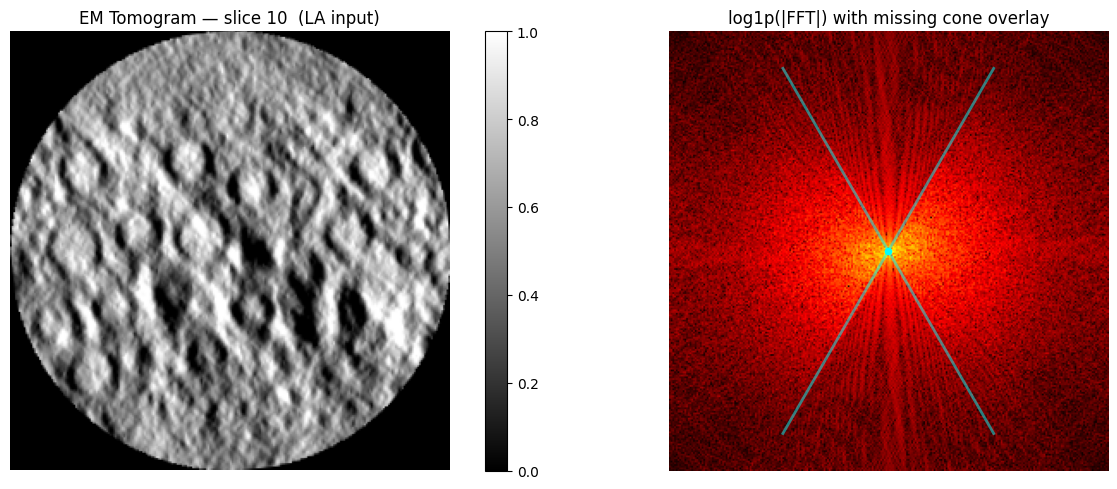

Slice range: [0.0000, 1.0000]


In [6]:
def fft_2D(x, dim=(-1, -2)):
    return torch.fft.fftshift(torch.fft.fftn(x, dim=dim), dim=dim)

def draw_missing_cone(ax, shape, cone_width_deg, gamma_deg, color='cyan', alpha=0.0, lw=2):
    gamma_deg += 90  # Rotate by 90° to align with the tilt axis convention (0° = missing cone along +ky)
    h, w = shape
    cy = (h - 1) / 2
    cx = (w - 1) / 2
    radius = 0.48 * min(h, w)
    half_angle = cone_width_deg / 2

    def sector_polygon(center_deg, n=256):
        angles = np.linspace(center_deg - half_angle, center_deg + half_angle, n)
        angles_rad = np.deg2rad(angles)
        xs = cx + radius * np.cos(angles_rad)
        ys = cy - radius * np.sin(angles_rad)  # image coordinates: y points downward
        return np.r_[cx, xs, cx], np.r_[cy, ys, cy]

    # Draw the two opposite missing-cone sectors in the 2D Fourier slice.
    for center_deg in (gamma_deg, gamma_deg + 180):
        xs, ys = sector_polygon(center_deg)
        ax.fill(xs, ys, color=color, alpha=alpha)

        for boundary_deg in (center_deg - half_angle, center_deg + half_angle):
            theta = np.deg2rad(boundary_deg)
            x1 = cx + radius * np.cos(theta)
            y1 = cy - radius * np.sin(theta)
            ax.plot([cx, x1], [cy, y1], color=color, lw=lw, alpha=0.5)

    ax.scatter([cx], [cy], s=20, color=color)

PREVIEW_IDX = NUM_SLICES // 2
la_slice = la_fbp[PREVIEW_IDX]
iso_slice = isonet[PREVIEW_IDX]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(la_slice.numpy(), cmap='gray', vmin=metric_min, vmax=metric_max)
axes[0].set_title(f'EM Tomogram — slice {PREVIEW_IDX}  (LA input)')
axes[0].axis('off')
plt.colorbar(axes[0].images[0], ax=axes[0])

fft_mag = torch.log1p(torch.abs(fft_2D(la_slice)))
axes[1].imshow(fft_mag.numpy(), cmap='hot')
draw_missing_cone(
    axes[1],
    fft_mag.shape,
    cone_width_deg=CONE_WIDTH_DEG,
    gamma_deg=0.,
    color='cyan',
)
axes[1].set_title(f'log1p(|FFT|) with missing cone overlay')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Slice range: [{la_slice.min():.4f}, {la_slice.max():.4f}]")

## 6. Load Trained Diffusion Model

In [7]:
channels = (64, 64, 128, 128, 256, 256)
model = UNet2DModel(
    sample_size=SLICE_W,
    in_channels=2,    # x_t (noisy) + carved_x (conditioner)
    out_channels=1,   # noise prediction
    layers_per_block=2,
    block_out_channels=channels,
    down_block_types=(
        "DownBlock2D", "DownBlock2D", "DownBlock2D",
        "DownBlock2D", "AttnDownBlock2D", "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D", "AttnUpBlock2D", "UpBlock2D",
        "UpBlock2D", "UpBlock2D", "UpBlock2D",
    ),
    class_embed_type="timestep",   # cone angle beta encoded like a diffusion timestep
).to(device)

ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

print(f"Model loaded from {CHECKPOINT_PATH}")
print(f"  Parameters : {sum(p.numel() for p in model.parameters()):,}")
print(f"  in_channels=2 (x_t + carved_x)  out_channels=1")

Model loaded from /myhome/sdate/checkpoints/ddpm_ladiff_cond_ladiff_neuron.pt
  Parameters : 28,527,937
  in_channels=2 (x_t + carved_x)  out_channels=1


tensor[256, 256] n=65536 (0.2Mb) x∈[-3.206, 3.609] μ=0.273 σ=0.804 cuda:0

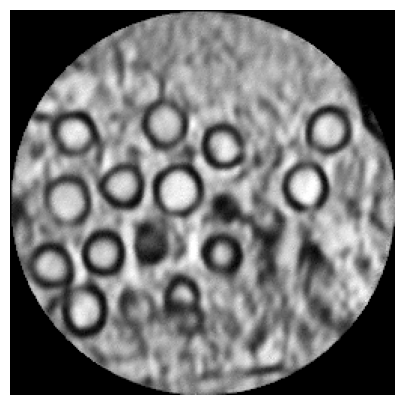

In [8]:

scheduler = GuidedDDIMScheduler(1000)
scheduler.set_timesteps(NUM_INFERENCE_STEPS)
timestep = 300
x = normalize_fn(iso_slice)
x_t = scheduler.add_noise(x, torch.randn_like(la_slice), timesteps=torch.tensor([timestep])).to(device)
with torch.no_grad():
    conditional_labels = torch.LongTensor([0.]).to(device)
    model_input = torch.stack([x_t, conditional_labels * x.to(device)], dim=0).to(device)  # (2, H, W)

    noise_pred = model(model_input.unsqueeze(0), timestep = torch.tensor([timestep]).to(device), class_labels=conditional_labels, return_dict=False)[0].squeeze()  # (H, W)
    x_0_pred = scheduler.step(noise_pred, timestep=timestep, sample=x_t)['pred_original_sample']  # (H, W)
    
    diffusion_pred = denormalize_fn(x_0_pred)
    # diffusion_pred = inpaint_guidance(
    #     source_volume=la_slice.unsqueeze(0).to(device),              # oracle: original full-angle tensor on device
    #     vol_init=diffusion_pred.unsqueeze(0).to(device)
    # )
plt.imshow(diffusion_pred.squeeze().cpu(), cmap='gray', vmin=metric_min, vmax=metric_max)
plt.axis('off')
x_t

## 7. Guidance Function

At each DDIM step the guidance function enforces Fourier consistency: it replaces the
known-data region of the DDIM prediction's Fourier volume with the corresponding
content from the original EM tomogram (`la_fbp`), leaving only the missing cone
region from the diffusion prediction.

In [9]:
from ladiff.recon_utils import inpaint_guidance as _inpaint_guidance

def inpaint_guidance(
    source_volume: torch.Tensor,
    vol_init: torch.Tensor,
    timestep: int = 0,
    inpaint_steps: int = 1,
) -> torch.Tensor:
    """Fourier inpainting guidance using the EM tomogram as data consistency source."""
    with torch.no_grad():
        x = _inpaint_guidance(
            source_volume=source_volume,
            vol_init=vol_init,
            angular_range_deg=ANGULAR_RANGE_DEG,
            start_angle=START_ANGLE,
            tilt_axis=TILT_AXIS,
            device=device,
            timestep=timestep,
            inpaint_steps=inpaint_steps,
        )
        x = torch.mean(x, dim=0).repeat(x.shape[0], 1, 1)  # average over slices to get a single slice (for testing)
    return x

# The guidance lambda passed to GuidedDDIMScheduler.
# source_volume = la_fbp (original EM data — no GT available)
guidance = lambda x, t: inpaint_guidance(
    source_volume=la_fbp.to(device),
    vol_init=x.to(device),
    timestep=int(t),
    inpaint_steps=1,
)

# guidance = lambda x, t,: x

print("Guidance function defined — uses la_fbp as data-consistency source")

Guidance function defined — uses la_fbp as data-consistency source


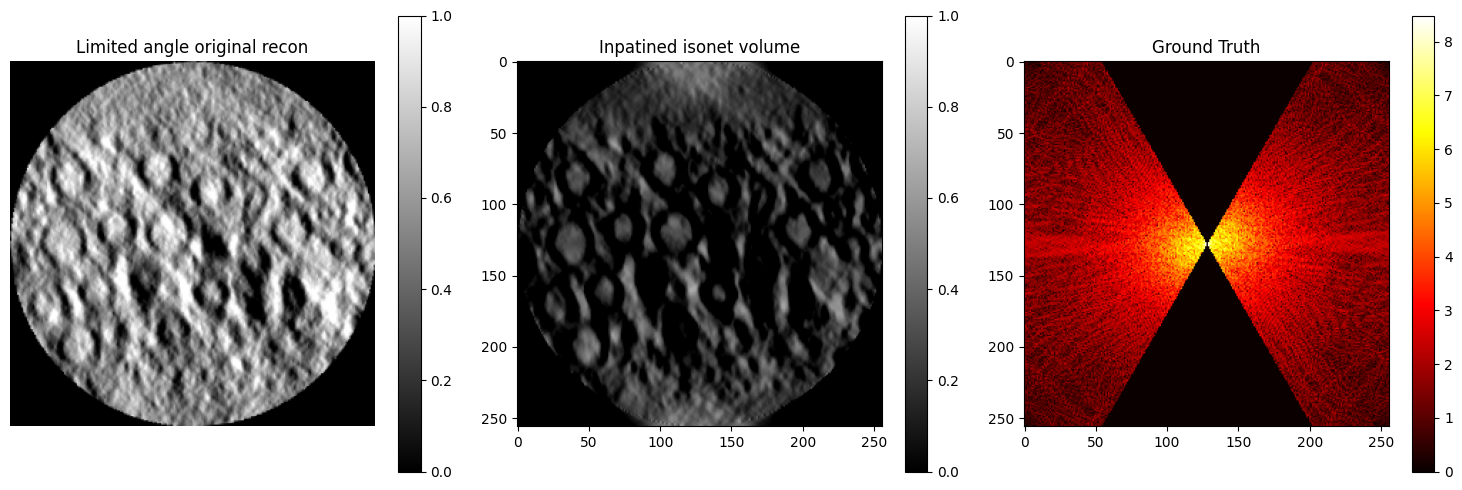

In [10]:
TEST_SLICE_IDX = NUM_SLICES // 2 
# Quick test: guidance from zero initialisation (uses SW projections since t=999 > threshold)
recons_gd = inpaint_guidance(
    source_volume=isonet.to(device),              # oracle: original full-angle tensor on device
    vol_init= 0*la_fbp.to(device),
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(la_fbp[TEST_SLICE_IDX].cpu().numpy(), cmap='gray', vmin=metric_min, vmax=metric_max)
axes[0].set_title('Limited angle original recon')
axes[0].axis('off')
plt.colorbar(axes[0].images[0], ax=axes[0])
axes[1].imshow(recons_gd[TEST_SLICE_IDX].cpu().numpy(), cmap='gray', vmin=metric_min, vmax=metric_max)
plt.colorbar(axes[1].images[0], ax=axes[1])
axes[1].set_title(f'Inpatined isonet volume')

# axes[2].imshow(isonet[TEST_SLICE_IDX].cpu().numpy(), cmap='gray', vmin=metric_min, vmax=metric_max)
axes[2].imshow(torch.log1p(torch.abs(fft_2D(recons_gd[TEST_SLICE_IDX].cpu()))), cmap='hot')
plt.colorbar(axes[2].images[0], ax=axes[2])
axes[2].set_title(f'Ground Truth')
plt.tight_layout()
plt.show()

## 8. Run Guided DDIM – Single Slice Sanity Check

Quick preview on the centre slice before running the full multi-slice sweep.

In [11]:
result_preview = la_fbp_orig[PREVIEW_IDX].unsqueeze(0).repeat(NUM_SLICES, 1, 1)

  0%|          | 0/40 [00:00<?, ?it/s]

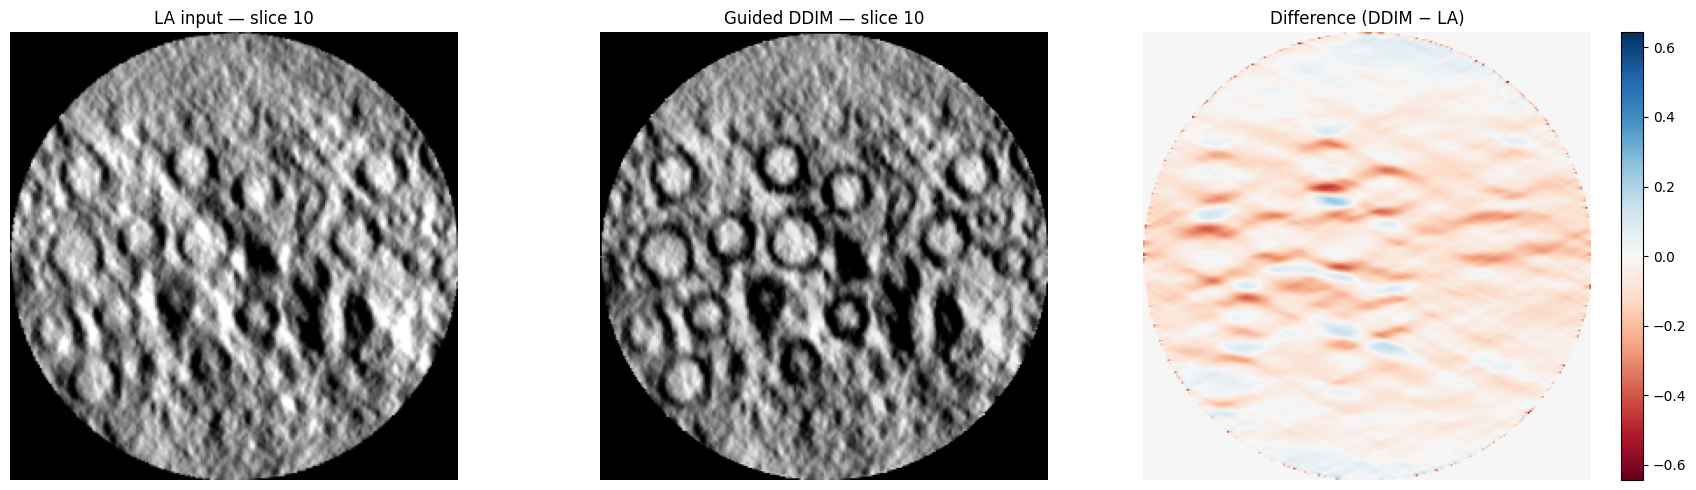

DDIM range: [-0.1740, 1.0443]


In [44]:
NUM_INFERENCE_STEPS = 40
torch.cuda.empty_cache()

noise_scheduler_preview = GuidedDDIMScheduler(
    num_train_timesteps=1000,
    guidance_function=guidance,
)

pipeline_preview = DDIMPipeline(
    unet=model.to(device),
    scheduler=noise_scheduler_preview,
    fdk_prior=result_preview.to(device),
    normalize_fn=normalize_fn,
    denormalize_fn=denormalize_fn,
    slice_batch_size=min(32, NUM_SLICES),
)

result_preview = pipeline_preview.truncated_pipeline(
    initial_guess=result_preview.to(device),
    start_step=int(0.0 * NUM_INFERENCE_STEPS),
    num_inference_steps=NUM_INFERENCE_STEPS,
    use_clipped_model_output=True,
    p_use_conditioning=0.7
).images

# #  Apply inpainting guidance to enforce data consistency
# result_preview = apply_circle_mask(inpaint_guidance(
#     source_volume=la_fbp.to(device),
#     vol_init=result_preview.to(device),
# ))



# Average over the Monte-Carlo batch to reduce noise
ddim_preview = result_preview[0]#.mean(dim=0)   # (H, W)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(la_fbp[PREVIEW_IDX].numpy(), cmap='gray', vmin=metric_min, vmax=metric_max)
axes[0].set_title(f'LA input — slice {PREVIEW_IDX}');  axes[0].axis('off')

axes[1].imshow(ddim_preview.cpu().numpy(), cmap='gray', vmin=metric_min, vmax=metric_max)
axes[1].set_title(f'Guided DDIM — slice {PREVIEW_IDX}');  axes[1].axis('off')

diff = (ddim_preview.cpu() - la_fbp[PREVIEW_IDX]).numpy()
emax = max(abs(diff.min()), abs(diff.max()))
axes[2].imshow(diff, cmap='RdBu', vmin=-emax, vmax=emax)
axes[2].set_title('Difference (DDIM − LA)');  axes[2].axis('off')
plt.colorbar(axes[2].images[0], ax=axes[2])

plt.tight_layout()
plt.show()

print(f"DDIM range: [{ddim_preview.min():.4f}, {ddim_preview.max():.4f}]")

## 9. Load IsoNet Baseline

IsoNet shape : torch.Size([20, 256, 256])  (expected: torch.Size([20, 256, 256]))
IsoNet range : [0.0000, 1.0000]  |  p1=0.0000  p99=0.9969


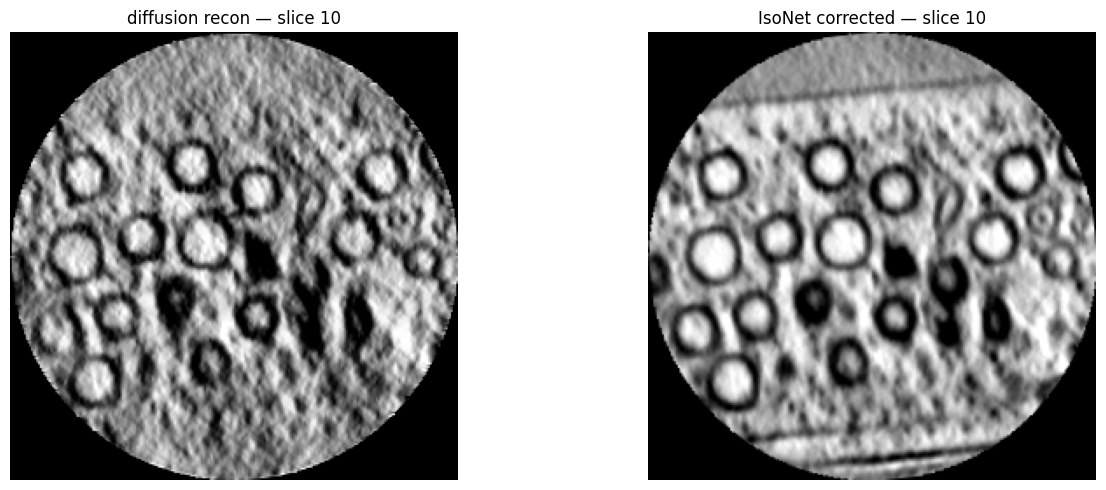

In [35]:


print(f"IsoNet shape : {isonet.shape}  (expected: {la_fbp.shape})")
assert isonet.shape == la_fbp.shape, "Shape mismatch between IsoNet and la_fbp volumes!"

iso_min = float(np.percentile(isonet.numpy(), 1))
iso_max = float(np.percentile(isonet.numpy(), 99))
print(f"IsoNet range : [{isonet.min():.4f}, {isonet.max():.4f}]  |  p1={iso_min:.4f}  p99={iso_max:.4f}")

# Use unified display range across both methods for fair comparison
disp_min = min(metric_min, iso_min)
disp_max = max(metric_max, iso_max)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(result_preview.cpu()[PREVIEW_IDX].numpy(),   cmap='gray', vmin=disp_min, vmax=disp_max)
axes[0].set_title(f'diffusion recon — slice {PREVIEW_IDX}');  axes[0].axis('off')
axes[1].imshow(isonet[PREVIEW_IDX].numpy(),   cmap='gray', vmin=disp_min, vmax=disp_max)
axes[1].set_title(f'IsoNet corrected — slice {PREVIEW_IDX}');  axes[1].axis('off')
plt.tight_layout()
plt.show()

## 10. Multi-Slice Evaluation

Sweep over selected slices and run the full Guided DDIM pipeline on each.
Since there is no ground truth, we collect per-slice results for qualitative
display and store them for the metrics section.

In [ ]:
from tqdm.auto import tqdm

# Determine which slices to evaluate
if TEST_SLICE_INDICES is not None:
    eval_slices = list(TEST_SLICE_INDICES)
else:
    eval_slices = list(range(0, NUM_SLICES, TEST_STRIDE))

print(f"Evaluating {len(eval_slices)} slices: {eval_slices[:8]}{'...' if len(eval_slices) > 8 else ''}")


results = []
for k in tqdm(eval_slices, desc='Guided DDIM sweep'):
    torch.cuda.empty_cache()

    # Build a volume of copies of slice k for Monte-Carlo averaging
    slice_vol = la_fbp[k].unsqueeze(0).repeat(NUM_SLICES, 1, 1)

    _sched = GuidedDDIMScheduler(
        num_train_timesteps=1000,
        guidance_function=guidance,
    )
    _pipe = DDIMPipeline(
        unet=model.to(device),
        scheduler=_sched,
        fdk_prior=slice_vol.to(device),
        normalize_fn=normalize_fn,
        denormalize_fn=denormalize_fn,
        slice_batch_size=NUM_SLICES,
    )

    res = _pipe.truncated_pipeline(
        initial_guess=slice_vol.to(device),
        start_step=int(0.2 * NUM_INFERENCE_STEPS),
        num_inference_steps=NUM_INFERENCE_STEPS,
        use_clipped_model_output=True,
    )
    # Average across the Monte-Carlo batch
    ddim_k = res.images.mean(dim=0).cpu().numpy()   # (H, W)

    la_k     = la_fbp[k].numpy()
    isonet_k = isonet[k].numpy()
    dr       = disp_max - disp_min

    # Pairwise SSIM as no-reference proxy (no GT)
    ssim_vs_la     = compute_ssim(la_k,     ddim_k,  data_range=dr)
    ssim_vs_isonet = compute_ssim(isonet_k, ddim_k,  data_range=dr)

    results.append({
        'slice':          k,
        'ddim_recon':     ddim_k,
        'la_fbp':         la_k,
        'isonet':         isonet_k,
        'ssim_vs_la':     ssim_vs_la,
        'ssim_vs_isonet': ssim_vs_isonet,
    })

print(f"\nDone — {len(results)} slices evaluated.")

## 11. Metrics Summary

No ground truth is available, so we report **pairwise SSIM** as a proxy:
- **SSIM(DDIM, LA-FBP)**: how similar the DDIM output is to the original EM input (data consistency).
- **SSIM(DDIM, IsoNet)**: agreement between the two correction methods.

Higher SSIM vs IsoNet suggests the methods agree on the restored content.

In [ ]:
ssim_la_all     = [r['ssim_vs_la']     for r in results]
ssim_isonet_all = [r['ssim_vs_isonet'] for r in results]
slices_all      = [r['slice']           for r in results]

# ── Per-slice table ───────────────────────────────────────────────────────
print(f"{'Slice':>6}  {'SSIM(DDIM,LA)':>14} {'SSIM(DDIM,IsoNet)':>18}")
print("-" * 44)
for r in results:
    print(f"{r['slice']:>6d}  {r['ssim_vs_la']:>14.4f} {r['ssim_vs_isonet']:>18.4f}")
print("-" * 44)
print(f"{'Mean':>6}  {np.mean(ssim_la_all):>14.4f} {np.mean(ssim_isonet_all):>18.4f}")
print(f"{'Std':>6}  {np.std(ssim_la_all):>14.4f} {np.std(ssim_isonet_all):>18.4f}")

# ── SSIM over slices ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(slices_all, ssim_la_all,     'o-',  label='SSIM(DDIM, LA-FBP)')
ax.plot(slices_all, ssim_isonet_all, 's--', label='SSIM(DDIM, IsoNet)')
ax.set_xlabel('Slice index')
ax.set_ylabel('SSIM')
ax.set_title('Per-slice pairwise SSIM (no ground truth)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Visual Comparison Gallery

Three-row grid: **LA-FBP | Guided DDIM | IsoNet** (real space)
plus a fourth row showing **log1p(|FFT|)** to visualise how well each method fills the missing cone.

In [ ]:
show_results = results[::max(1, len(results) // 4)][:4]
ncols = len(show_results)

fig, axes = plt.subplots(4, ncols, figsize=(5 * ncols, 20))
if ncols == 1:
    axes = axes.reshape(-1, 1)

row_labels = ['LA-FBP', 'Guided DDIM', 'IsoNet', 'FFT log-mag (DDIM)']

for col, r in enumerate(show_results):
    k        = r['slice']
    la_k     = r['la_fbp']
    ddim_k   = r['ddim_recon']
    isonet_k = r['isonet']

    # Row 0 – LA input
    axes[0, col].imshow(la_k,     cmap='gray', vmin=disp_min, vmax=disp_max)
    axes[0, col].set_title(f'LA-FBP – slice {k}'); axes[0, col].axis('off')

    # Row 1 – Guided DDIM
    axes[1, col].imshow(ddim_k,   cmap='gray', vmin=disp_min, vmax=disp_max)
    axes[1, col].set_title(
        f'Guided DDIM\nSSIM(LA)={r["ssim_vs_la"]:.3f}  SSIM(Iso)={r["ssim_vs_isonet"]:.3f}'
    )
    axes[1, col].axis('off')

    # Row 2 – IsoNet
    axes[2, col].imshow(isonet_k, cmap='gray', vmin=disp_min, vmax=disp_max)
    axes[2, col].set_title(f'IsoNet – slice {k}'); axes[2, col].axis('off')

    # Row 3 – FFT log-magnitude of DDIM recon
    fft_mag = torch.log1p(torch.abs(fft_2D(torch.tensor(ddim_k))))
    axes[3, col].imshow(fft_mag.numpy(), cmap='hot')
    axes[3, col].set_title(f'DDIM FFT — slice {k}'); axes[3, col].axis('off')

# Shared row labels
for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=10, rotation=90, labelpad=5)

plt.suptitle('Guided DDIM vs LA-FBP vs IsoNet — qualitative comparison', fontsize=14)
plt.tight_layout()
plt.show()

## 13. Iterative Refinement Loop

Re-run the Guided DDIM pipeline for `NUM_OUTER_ITERS` outer iterations.
The mean reconstruction (averaged over the Monte-Carlo batch) is used as the initial
guess for the next iteration.  Since there is no GT, we track:
- `SSIM(iter_recon, IsoNet)` — agreement with IsoNet
- `SSIM(iter_recon, LA-FBP)` — data consistency proxy

In [ ]:
NUM_INFERENCE_STEPS_ITER = 40
# START_STEP_FRACS         = [0.0, 0.2, 0.4, 0.6] + 4 * [0.8]    # start step as fraction of NUM_INFERENCE_STEPS_ITER
# NUM_OUTER_ITERS          = 1

START_STEP_FRACS = [0.8]
NUM_OUTER_ITERS = 20

# Operate on the full volume for the iterative loop
# iterative_recon = la_fbp.clone().to(device)

iter_metrics   = []   # list of dicts
iter_snapshots = {}   # (outer_iter, frac) → numpy array

# Use a fixed slice for per-iteration monitoring
mid          = NUM_SLICES // 2
iso_mid_np   = isonet[mid].numpy()
la_mid_np    = la_fbp[mid].numpy()
dr_mid       = disp_max - disp_min

for outer_iter in range(NUM_OUTER_ITERS):
    print(f"\n── Outer iteration {outer_iter + 1}/{NUM_OUTER_ITERS} ──────────")
    for start_step_frac in START_STEP_FRACS:
        torch.cuda.empty_cache()

        _sched = GuidedDDIMScheduler(
            num_train_timesteps=1000,
            guidance_function=guidance,
        )
        _pipe = DDIMPipeline(
            unet=model.to(device),
            scheduler=_sched,
            fdk_prior=la_fbp.clone().to(device),
            normalize_fn=normalize_fn,
            denormalize_fn=denormalize_fn,
            slice_batch_size=32,
        )

        result_iter = _pipe.truncated_pipeline(
            initial_guess=iterative_recon.to(device),
            start_step=int(start_step_frac * NUM_INFERENCE_STEPS_ITER),
            num_inference_steps=NUM_INFERENCE_STEPS_ITER,
            use_clipped_model_output=True,
        )
        iterative_recon = result_iter.images   # (N, H, W)

        # # Apply inpainting guidance to enforce data consistency
        # iterative_recon = apply_circle_mask(inpaint_guidance(
        #     source_volume=la_fbp.to(device),
        #     vol_init=iterative_recon.to(device),
        # ))

        # Mean reconstruction across slice batch (all slices treated equally here)
        mean_recon = iterative_recon.mean(dim=0, keepdim=True).repeat(NUM_SLICES, 1, 1)
        mean_recon = apply_circle_mask(inpaint_guidance(
            source_volume=la_fbp.to(device),
            vol_init=mean_recon.to(device),
        ))

        # ── Proxy metrics on monitoring slice ────────────────────────────
        full_mid_np = iterative_recon[mid].cpu().numpy()
        mean_mid_np = mean_recon[mid].cpu().numpy()

        ssim_full_iso = compute_ssim(iso_mid_np, full_mid_np, data_range=dr_mid)
        ssim_mean_iso = compute_ssim(iso_mid_np, mean_mid_np, data_range=dr_mid)
        ssim_full_la  = compute_ssim(la_mid_np,  full_mid_np, data_range=dr_mid)
        ssim_mean_la  = compute_ssim(la_mid_np,  mean_mid_np, data_range=dr_mid)

        iter_metrics.append({
            'outer_iter':      outer_iter,
            'start_step_frac': start_step_frac,
            'ssim_full_iso':   ssim_full_iso,
            'ssim_mean_iso':   ssim_mean_iso,
            'ssim_full_la':    ssim_full_la,
            'ssim_mean_la':    ssim_mean_la,
        })
        iter_snapshots[(outer_iter, start_step_frac)] = mean_mid_np.copy()

        print(f"  frac={start_step_frac:.2f}  "
              f"SSIM(full,Iso)={ssim_full_iso:.4f}  SSIM(mean,Iso)={ssim_mean_iso:.4f}  |  "
              f"SSIM(full,LA)={ssim_full_la:.4f}  SSIM(mean,LA)={ssim_mean_la:.4f}")

        iterative_recon = mean_recon.to(device)

print("\nIterative refinement done ✓")

In [ ]:
# ── Convergence curves ────────────────────────────────────────────────────
iters_x       = [m['outer_iter'] + 1    for m in iter_metrics]
ssim_full_iso = [m['ssim_full_iso']     for m in iter_metrics]
ssim_mean_iso = [m['ssim_mean_iso']     for m in iter_metrics]
ssim_full_la  = [m['ssim_full_la']      for m in iter_metrics]
ssim_mean_la  = [m['ssim_mean_la']      for m in iter_metrics]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(iters_x, ssim_full_iso, 'o--', color='C0', alpha=0.5, label='full vs IsoNet')
axes[0].plot(iters_x, ssim_mean_iso, 'o-',  color='C0',             label='mean vs IsoNet')
axes[0].set_xlabel('Outer iteration'); axes[0].set_ylabel('SSIM')
axes[0].set_title('SSIM(DDIM, IsoNet) — iterative refinement')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

axes[1].plot(iters_x, ssim_full_la, 'o--', color='C1', alpha=0.5, label='full vs LA-FBP')
axes[1].plot(iters_x, ssim_mean_la, 'o-',  color='C1',             label='mean vs LA-FBP')
axes[1].set_xlabel('Outer iteration'); axes[1].set_ylabel('SSIM')
axes[1].set_title('SSIM(DDIM, LA-FBP) — data consistency')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Best iteration gallery ─────────────────────────────────────────────────
best_idx   = int(np.argmax(ssim_mean_iso))
best_iter  = iter_metrics[best_idx]['outer_iter']
best_snap  = iter_snapshots[(best_iter, START_STEP_FRACS[-1])]

# Last iterate
last_snap = iterative_recon[mid].cpu().numpy()
ssim_last_iso = compute_ssim(iso_mid_np, last_snap, data_range=dr_mid)

fig, axes = plt.subplots(1, 4, figsize=(24, 5))
axes[0].imshow(la_mid_np,  cmap='gray', vmin=disp_min, vmax=disp_max)
axes[0].set_title(f'LA-FBP — slice {mid}'); axes[0].axis('off')
axes[1].imshow(best_snap,  cmap='gray', vmin=disp_min, vmax=disp_max)
axes[1].set_title(f'Best DDIM (iter {best_iter+1})\nSSIM(Iso)={ssim_mean_iso[best_idx]:.4f}')
axes[1].axis('off')
axes[2].imshow(last_snap,  cmap='gray', vmin=disp_min, vmax=disp_max)
axes[2].set_title(f'Last DDIM (iter {NUM_OUTER_ITERS})\nSSIM(Iso)={ssim_last_iso:.4f}')
axes[2].axis('off')
axes[3].imshow(iso_mid_np, cmap='gray', vmin=disp_min, vmax=disp_max)
axes[3].set_title(f'IsoNet — slice {mid}'); axes[3].axis('off')
plt.suptitle(f'Best and Last iterative refinement results vs IsoNet  (slice {mid})', fontsize=12)
plt.tight_layout()
plt.show()

## 14. Save Results

In [ ]:
import os

OUT_PATH = RECON_PATH / 'ddim_corrected.npy'
OUT_METRICS_PATH = RECON_PATH / 'ddim_metrics.json'

# Save the final iterative reconstruction
final_np = iterative_recon.cpu().numpy()
np.save(OUT_PATH, final_np)
print(f"Saved DDIM reconstruction → {OUT_PATH}")
print(f"  shape: {final_np.shape}  range: [{final_np.min():.4f}, {final_np.max():.4f}]")

# Save per-slice metrics as JSON
metrics_out = [
    {k: v for k, v in r.items() if k not in ('ddim_recon', 'la_fbp', 'isonet')}
    for r in results
]
with open(OUT_METRICS_PATH, 'w') as f:
    json.dump(metrics_out, f, indent=2)
print(f"Saved per-slice metrics  → {OUT_METRICS_PATH}")